# Chest X-Ray Pneumonia Detection (CNN + Transfer Learning)

This notebook builds a binary image classifier that detects **pneumonia vs. normal** from chest X-ray images, using transfer learning with **MobileNetV2** pretrained on ImageNet.

**Dataset:** [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) by Paul Mooney on Kaggle (~5,800 images).

**Before you start:**
1. Go to `Runtime` -> `Change runtime type` -> set Hardware accelerator to **GPU** (T4 is fine).
2. If you don't have a Kaggle account, make one for free at kaggle.com.
3. Go to kaggle.com/settings -> **Create New API Token**. This downloads a file called `kaggle.json` - you'll upload it in Step 1 below.

Run the cells top to bottom.

In [16]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 1: Get the dataset from Kaggle

In [17]:
!pip install -q kaggle
from google.colab import files
print("Upload your kaggle.json file (from kaggle.com/settings):")
files.upload()

Upload your kaggle.json file (from kaggle.com/settings):


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sresthabiswas","key":"bb3c70ee24db2134e2333072e101b4f2"}'}

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data
print("Download and extraction complete.")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:59<00:00, 41.7MB/s]

Download and extraction complete.


## Step 2: Locate the dataset folders

This Kaggle dataset sometimes extracts with an extra nested folder. This cell finds the real `train` and `test` folders automatically so you don't have to guess the path.

In [4]:
extract_root = '/content/chest_xray_data'
train_dir = test_dir = None

for root, dirs, files_ in os.walk(extract_root):
    if 'NORMAL' in dirs and 'PNEUMONIA' in dirs:
        folder_name = os.path.basename(root)
        if folder_name == 'train':
            train_dir = root
        elif folder_name == 'test':
            test_dir = root

print("train_dir:", train_dir)
print("test_dir:", test_dir)

print("Train NORMAL images:", len(os.listdir(os.path.join(train_dir, 'NORMAL'))))
print("Train PNEUMONIA images:", len(os.listdir(os.path.join(train_dir, 'PNEUMONIA'))))

train_dir: /content/chest_xray_data/chest_xray/chest_xray/train
test_dir: /content/chest_xray_data/chest_xray/chest_xray/test
Train NORMAL images: 1342
Train PNEUMONIA images: 3876


## Step 3: Set up data generators

We use `ImageDataGenerator` for on-the-fly augmentation and resizing. Note: the dataset's own `val` folder only has 16 images, which is too small to trust - so instead we carve out 20% of the `train` folder as our validation set.

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## Step 4: Look at a few sample images

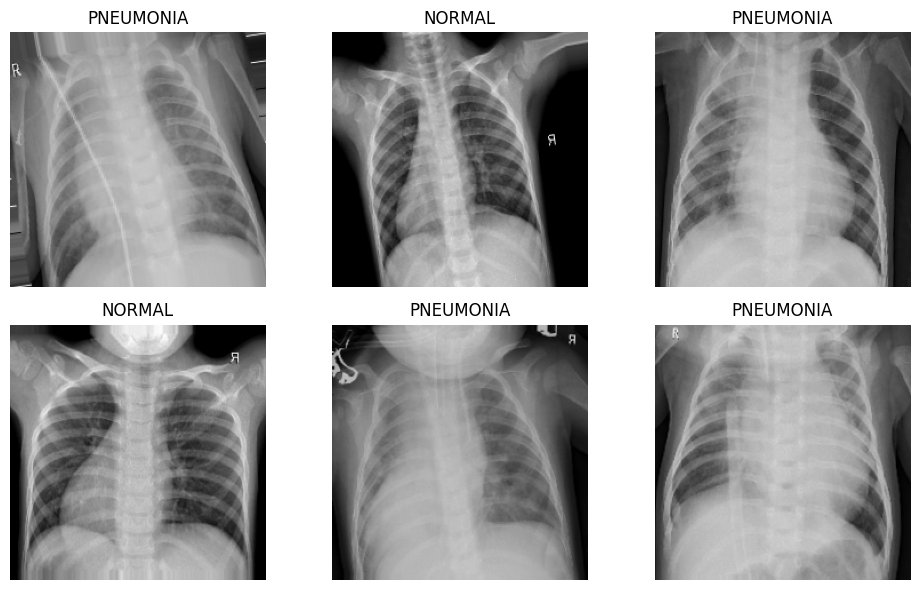

In [6]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)
class_names = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 5: Build the model (MobileNetV2 + transfer learning)

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze pretrained layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 6: Handle class imbalance

There are more pneumonia images than normal images in this dataset, so we weight classes to keep the model from just favoring the majority class.

In [8]:
from sklearn.utils import class_weight
import numpy as np

labels_train = train_generator.classes
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_train),
    y=labels_train
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


## Step 7: Train the model

This usually takes 10-20 minutes total on Colab's free GPU.

In [9]:
EPOCHS = 8

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.8447 - loss: 0.3497 - val_accuracy: 0.9070 - val_loss: 0.2278
Epoch 2/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 811ms/step - accuracy: 0.9159 - loss: 0.2018 - val_accuracy: 0.9147 - val_loss: 0.2005
Epoch 3/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 796ms/step - accuracy: 0.9240 - loss: 0.1804 - val_accuracy: 0.9166 - val_loss: 0.1891
Epoch 4/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 797ms/step - accuracy: 0.9365 - loss: 0.1497 - val_accuracy: 0.9310 - val_loss: 0.1621
Epoch 5/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 791ms/step - accuracy: 0.9406 - loss: 0.1414 - val_accuracy: 0.9425 - val_loss: 0.1426
Epoch 6/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 792ms/step - accuracy: 0.9485 - loss: 0.1196 - val_accuracy: 0.9377 - val_loss: 0.1550
Epoch 7/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 799ms/step - accuracy: 0.9490 - loss: 0.1256 - val_accuracy: 0.9434 - val_loss: 0.1392
Epoch 8/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 802ms/step - accuracy: 0.9523 - loss: 0.12

## Step 8: Plot training curves

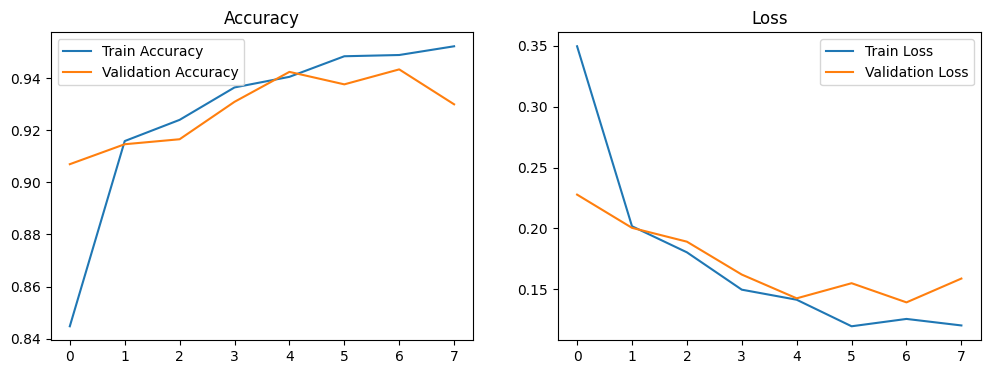

In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

## Step 9: Evaluate on the test set

In [11]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 844ms/step - accuracy: 0.8926 - loss: 0.2291
Test Accuracy: 0.8926
Test Loss: 0.2291


## Step 10: Confusion matrix and classification report

Accuracy alone can be misleading in medical data - precision and recall per class matter more, since a missed pneumonia case (false negative) is worse than a false alarm.

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 438ms/step
              precision    recall  f1-score   support

      NORMAL       0.89      0.81      0.85       234
   PNEUMONIA       0.89      0.94      0.92       390

    accuracy                           0.89       624
   macro avg       0.89      0.88      0.88       624
weighted avg       0.89      0.89      0.89       624



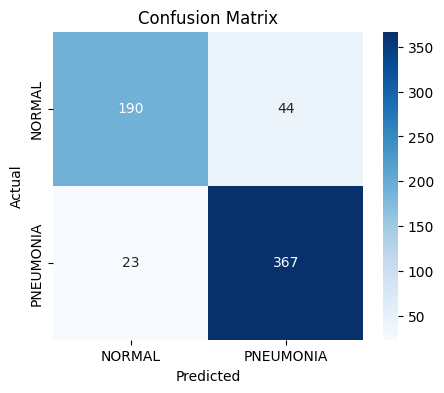

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_generator.reset()
predictions = model.predict(test_generator)
predicted_labels = (predictions > 0.5).astype(int).flatten()
true_labels = test_generator.classes
class_names_list = list(test_generator.class_indices.keys())

print(classification_report(true_labels, predicted_labels, target_names=class_names_list))

cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_list, yticklabels=class_names_list)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Step 11: Look at some individual predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


/tmp/ipykernel_316/2852270559.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = class_names_list[int(preds[i] > 0.5)]


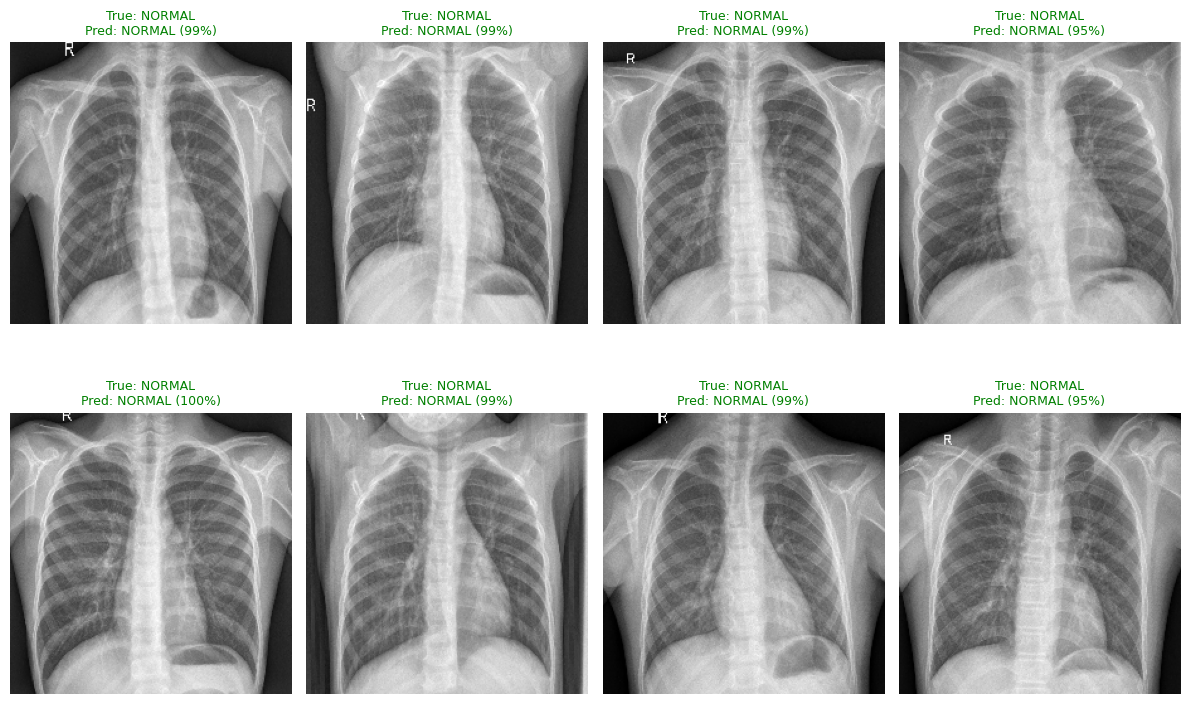

In [13]:
test_generator.reset()
images, labels = next(test_generator)
preds = model.predict(images)

plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    true_label = class_names_list[int(labels[i])]
    pred_label = class_names_list[int(preds[i] > 0.5)]
    confidence = preds[i][0] if preds[i] > 0.5 else 1 - preds[i][0]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0%})", color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 12: Save the model

In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Re-instantiate the model structure so the 'model' variable is defined
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("Model structure rebuilt. You can now save the model structure, or run 'Step 7' first to train it before saving.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model structure rebuilt. You can now save the model structure, or run 'Step 7' first to train it before saving.


In [7]:
model.save('pneumonia_cnn_model.keras')
print("Model saved as pneumonia_cnn_model.keras")

Model saved as pneumonia_cnn_model.keras


## Optional bonus (if you have extra time): Grad-CAM visualization

This shows which parts of the X-ray the model is "looking at" when it makes a prediction - a strong addition for a healthcare project since it addresses model interpretability.

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


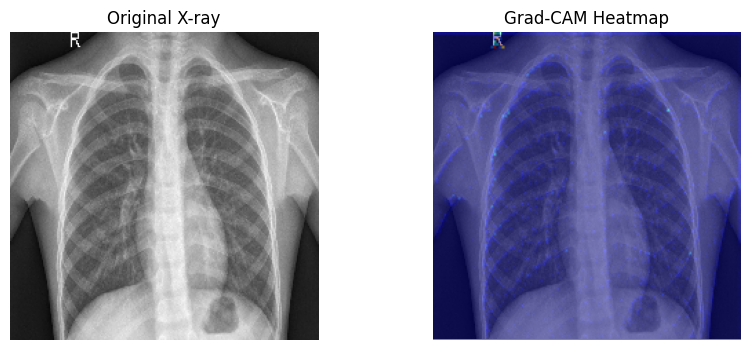

In [15]:
import numpy as np
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

last_conv_layer_name = [layer.name for layer in base_model.layers if 'conv' in layer.name][-1]

test_generator.reset()
sample_images, sample_labels = next(test_generator)
img_array = np.expand_dims(sample_images[0], axis=0)

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_images[0])
plt.title("Original X-ray")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample_images[0])
plt.imshow(heatmap, cmap='jet', alpha=0.5, extent=(0, 224, 224, 0))
plt.title("Grad-CAM Heatmap")
plt.axis('off')
plt.show()

## Next: upload to GitHub

1. Download this notebook: `File` -> `Download` -> `Download .ipynb`.
2. Go to your GitHub repo and upload it along with `README.md`, `requirements.txt`, and `LICENSE` - same process you used for your Iris project.
3. In your README, fill in your actual test accuracy and add a screenshot of your confusion matrix and a couple of prediction examples.